### 7. I koden nedan använder vi datasetet "housing.csv" som användes i kapitel 2. 

```python

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

df = pd.read_csv("housing.csv")
X = df.loc[:, ["median_income", "latitude", "longitude"]]
print(X.head())

kmeans = KMeans(n_clusters=6)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")
print(X.head())

sns.relplot(
    x="longitude", y="latitude", hue="Cluster", data=X, height=6,
)
```


### a) Förklara vad koden gör. 

Koden läser först in `housing.csv`. Sedan väljer den ut tre kolumner: **medianinkomst**, **latitud** och **longitud** för varje område i datan.

Efter det delar K-means upp områdena i sex olika grupper. Varje område får ett nummer mellan 0 och 5 beroende på vilken grupp det hamnar i.

Till sist ritar koden ett spridningsdiagram där varje punkts position motsvarar områdets geografiska läge (longitud/latitud), och färgen visar vilket kluster området tillhör. Eftersom koordinaterna följer den geografiska verkligheten liknar diagrammet en karta, även om det bara är en vanlig scatterplot.

### b) I koden har vi sex kluster (0-5). I verkligheten hade man kunnat undersöka respektive kluster för att se vilka preferenser de har, t.ex. hur de föredrar att bli kontaktade, vilka hustyper de gillar och dylikt. Om du hade lett en undersökning, vilken information hade du velat ha om respektive kluster och hur hade du designat marknadsundersökningen?

Jag skulle vilja veta:
- **Demografi**: Ålder, inkomst, familjestorlek
- **Boendepreferenser**: Storlek, pris, typ av bostad (lägenhet/villa/hus)
- **Kontakt**: Hur vill de bli kontaktade (e-post, telefon, webb)?
- **Budget**: Hur mycket pengar har de?
- **Tidplan**: När planerar de att köpa?

**Undersökningsdesign:**
1. Varje kluster motsvarar ett geografiskt område, inte färdiga svarspersoner. Man skulle behöva rekrytera boende inom respektive områdes kluster, t.ex. via lokala mäklare eller riktade annonser.
2. Ta ett proportionerligt urval från varje kluster, så att kluster med fler områden också får fler svarande, istället för samma antal (t.ex. 100) i varje kluster oavsett storlek.
3. Skicka en enkät med frågor om det ovan.
4. Jämför svaren mellan klustren och se vilka skillnader det finns.
5. Använd informationen för att göra olika marknadsstrategier för varje kluster.

### c) Det som tagits fram, hur kan det vara användbart i verkligheten för ett företag exempelvis?

Ett företag kan använda informationen för att förstå sina kunder bättre i olika områden. Om ett kluster till exempel har hög inkomst och föredrar villor kan företaget rikta annonser om större bostäder dit, medan ett kluster med lägre inkomst istället kan få annonser om lägenheter till lägre pris. Det gör marknadsföringen mer träffsäker eftersom rätt budskap visas för rätt grupp, istället för samma generella annons till alla.

### d) Vi har gjort ett enkelt kodexempel, lek gärna runt och fortsätt utveckla det. Exempelvis kan du undersöka hur många kluster som vore bra att använda. 

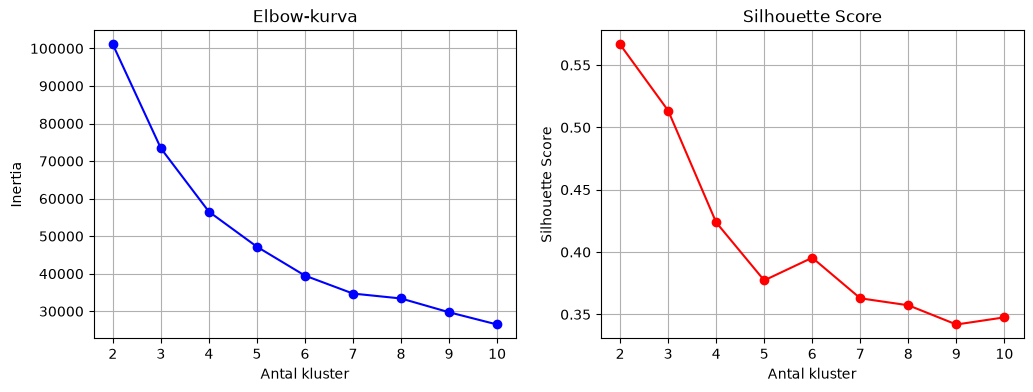

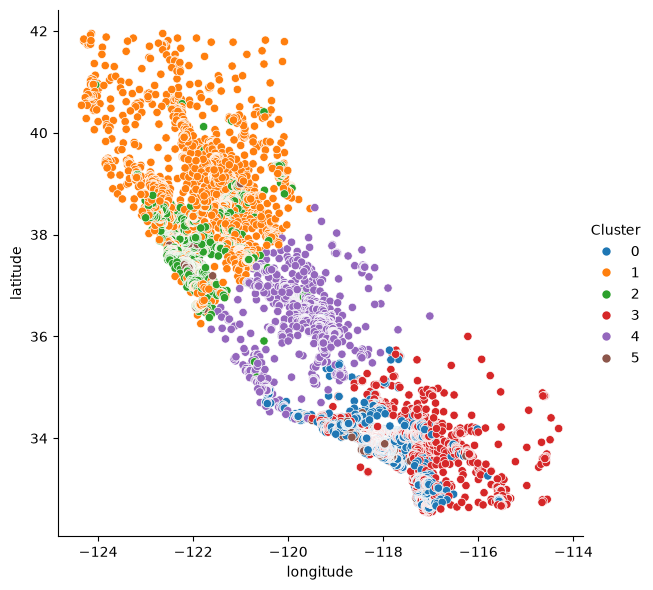

In [2]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../data/housing.csv")
X = df.loc[:, ["median_income", "latitude", "longitude"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertias, "bo-")
plt.xlabel("Antal kluster")
plt.ylabel("Inertia")
plt.title("Elbow-kurva")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, "ro-")
plt.xlabel("Antal kluster")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.grid()
plt.show()

best_k = 6
kmeans = KMeans(n_clusters=best_k, random_state=42)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")

sns.relplot(x="longitude", y="latitude", hue="Cluster", data=X, height=6)